# The Native Bridge — why the real engine is *not* the ideal SDF

### A structural mismatch, not a calibration failure

*Strobo-Travels-Deep · `wp-wigner-tomography` · explanatory notebook · 2026-05-17*

The first three notebooks lived entirely in the **ideal** layer: an
idealised σ_x state-dependent force, its χ→Wigner inversion, and the
Dirichlet targeting that places the probe points. This capstone
explains the relationship between that ideal layer and the **real
simulation engine** — and answers the question the whole series
quietly raised: *why did WP-W have to supply the ideal SDF as a
separate primitive at all, instead of just running the engine?*

**The one-sentence answer.** The monochromatic Raman Hamiltonian the
engine implements is a **different operator** from the FH20-style
bichromatic SDF — no scalar knob, drive strength, or calibration
turns one into the other. WP-W proves this with three independent
pieces of executed evidence; this notebook lays them out.

**Where this sits in WP-W.** This is the §7#3 / `analytic_chain.md`
§5 "structural bridge" finding, made readable, tying together the
P1, D4-A, D4-B and back-action artefacts. Teaching artefact; the
sources below are authoritative.

| Authoritative source | Where |
|---|---|
| The structural argument | [`notes/analytic_chain.md`](../wp-wigner-tomography/notes/analytic_chain.md) §5 |
| Work program | [`WORK-PROGRAM.md`](../wp-wigner-tomography/WORK-PROGRAM.md) §7#3 |
| D4 bridge logbook | [`logbook/2026-05-15-D4-bridge.md`](../wp-wigner-tomography/logbook/2026-05-15-D4-bridge.md) |
| Committed data | `p1_preflight.h5`, `bridge_native.json`, `bridge_inversion.h5`, `back_action.h5` |

## §1 Plain-language definitions

Read once; the rest of the notebook uses these words in this sense.

- **Native engine.** The actual simulation model in
  `scripts/stroboscopic` — a *monochromatic* Raman drive (one
  laser-beat tone). It is the "real physics" the lab runs and what
  WP-E / WP-TOM also use.

- **Ideal SDF.** The FH20-style *bichromatic* state-dependent force
  $U=D(\sigma_x\beta/2)$ — a clean, spin-eigenstate-conditioned
  displacement. WP-W's reconstruction maths assumes this. It is
  supplied numerically as a separate primitive (`ideal_sdf`), **not**
  produced by the native engine.

- **Structural mismatch.** A difference between two models that comes
  from them being *different operators* — different terms in the
  Hamiltonian — rather than the same operator with mis-set numbers.
  A structural mismatch **cannot** be removed by calibration; it can
  only be characterised.

- **Bridge residual.** A *measured* number that quantifies how far
  the native engine sits from the ideal SDF (or how well two
  implementations of the same thing agree). WP-W keeps three, each
  probing a different link.

- **Two layers, kept separate.** WP-W deliberately separates (a) the
  **ideal-SDF tomography claim** — clean, validated, the subject of
  notebooks 1–3 — from (b) the **native-engine bridge** — a measured
  diagnostic, never a fidelity gate. This notebook is about (b).

## §2 The two operators, precisely

The ideal SDF is a **spin-eigenstate-conditioned displacement**:

$$U_\mathrm{SDF}(\beta)=D\!\big(\sigma_x\tfrac{\beta}{2}\big)
\;\;\Rightarrow\;\;
|{\pm}x\rangle \text{ branch displaced by } \pm\beta/2 .$$

The native engine implements a **monochromatic Raman** Hamiltonian
(`analytic_chain.md` §5):

$$H_\mathrm{eng}=\tfrac{\delta}{2}\sigma_z
+\tfrac{\Omega_r}{2}\big(e^{i\varphi}C\,\sigma_-+e^{-i\varphi}C^\dagger\sigma_+\big),
\qquad C=e^{i\eta X},\; X=a+a^\dagger.$$

Expanding the Lamb–Dicke factor $C$, the coupling is a **carrier
spin rotation** plus a **transverse, position-dependent spin
rotation** — *not* a spin-eigenstate-conditioned displacement. At
sideband resonance $\delta=+\omega_m$ the leading motional term
becomes, under the rotating-wave approximation, a **Jaynes–Cummings**
coupling $a\,\sigma^-_{\varphi+\pi/2}+\text{h.c.}$ — still
*spin-flip ⊗ phonon-flip*, never $D(\sigma_x\beta/2)$. **No limit**
of the monochromatic engine — no drive strength, no detuning, no
pulse count — recovers $U_\mathrm{SDF}$; only a *bichromatic*
(simultaneous red+blue, Mølmer–Sørensen-type) drive does. That is
the structural mismatch: two different operators. It is *derived*,
not fitted — see `analytic_chain.md` §5 (this notebook does not
re-derive it; it shows the executed evidence).

## §3 Setup

In [1]:
import os, sys, json, hashlib, subprocess
import numpy as np
import h5py
import matplotlib.pyplot as plt

REPO = os.path.abspath(os.path.join(os.getcwd(), ".."))
NUM = os.path.join(REPO, "wp-wigner-tomography", "numerics")

def _sha(path):
    h = hashlib.sha256()
    with open(path, "rb") as fh:
        for blk in iter(lambda: fh.read(65536), b""):
            h.update(blk)
    return h.hexdigest()

plt.rcParams.update({"figure.dpi": 110})
for n in ("p1_preflight.h5", "bridge_native.json", "bridge_inversion.h5",
          "back_action.h5"):
    print(f"{n:24s}",
          "present" if os.path.exists(os.path.join(NUM, n)) else "MISSING")

p1_preflight.h5          present
bridge_native.json       present
bridge_inversion.h5      present
back_action.h5           present


## §3 Three independent pieces of evidence

The argument is a chain of three *separately verifiable* claims. If
all three hold, "structural mismatch, not calibration" is forced:

1. **The ideal-SDF maths is exact** (P1, and grid-wide via D4-B).
   → any later mismatch is not the inversion maths.
2. **The native engine is correctly implemented** — it reproduces an
   *independent* WP-E reference bit-for-bit (D4 Layer A).
   → any later mismatch is not an engine bug or miscalibration.
3. **Yet native and ideal, driven by the *same* program, produce
   structurally different motion** (back-action).
   → the only thing left is the operator itself: §2.

§4–§6 take these one at a time.

## §4 Evidence 1 — the ideal-SDF maths is exact

Deliverable **P1** drove the ideal-SDF primitive to a sentinel probe
point and read χ back; **D4 Layer B (fine)** did the same over the
*entire* $81^2$ reconstruction grid. Both compare *engine-measured χ*
(ideal primitive) against the closed-form analytic χ.

**What to look for:** the P1 point residuals sit at ~$10^{-14}$
(machine precision), and the D4-B grid-wide residual is
$3.75\times10^{-4}$ — the **canonical bridge metric**. (The D4-B
FFT-centroid number is *sub-pixel* at $\Delta\alpha=0.39$ and is
deliberately **not** the gate — the right metric is the
engine-vs-analytic χ residual; logbook §3.3.) Conclusion: the ideal
inversion chain is exact, point-wise and grid-wide.

In [2]:
with h5py.File(os.path.join(NUM, "p1_preflight.h5"), "r") as f:
    p1 = [(f[k].attrs["state"], int(f[k].attrs["N"]),
           float(f[k].attrs["abs_residual"]))
          for k in sorted(f) if k.startswith("point_")]
with h5py.File(os.path.join(NUM, "bridge_inversion.h5"), "r") as f:
    b_fine = float(f["fine"].attrs["chi_max_abs_residual_vs_analytic"])
    b_coarse = float(f["coarse"].attrs["chi_max_abs_residual_vs_analytic"])
    rW_fine = float(f.attrs["r_W_fine"]); da_fine = float(f["fine"].attrs["d_alpha"])

print("P1 (ideal-SDF primitive, engine chi vs analytic chi):")
for st, Np, res in p1:
    print(f"  {st:>13}  N={Np:<3}  |chi_eng - chi_an| = {res:.2e}")
print(f"\nD4 Layer B (ideal-SDF chi vs analytic chi over the grid):")
print(f"  fine  (N=80, 81^2): max|d| = {b_fine:.3e}   <- canonical bridge metric")
print(f"  coarse(N=20, 41^2): max|d| = {b_coarse:.3e}   "
      f"(out-of-branch coverage test: N=20 has reach B=1, so the outer "
      f"beta nodes are invalid; documented, not a defect)")
print(f"  FFT centroid r_W_fine = {rW_fine:.4f} at d_alpha = {da_fine:.3f} "
      f"-> sub-pixel ({rW_fine/da_fine:.0%} of one pixel); reported, NOT gated")

P1 (ideal-SDF primitive, engine chi vs analytic chi):
         vacuum  N=20   |chi_eng - chi_an| = 1.01e-14
         vacuum  N=80   |chi_eng - chi_an| = 3.02e-14
   coherent_1.0  N=20   |chi_eng - chi_an| = 4.10e-14
   coherent_1.0  N=80   |chi_eng - chi_an| = 4.05e-14

D4 Layer B (ideal-SDF chi vs analytic chi over the grid):
  fine  (N=80, 81^2): max|d| = 3.753e-04   <- canonical bridge metric
  coarse(N=20, 41^2): max|d| = 7.655e-01   (out-of-branch coverage test: N=20 has reach B=1, so the outer beta nodes are invalid; documented, not a defect)
  FFT centroid r_W_fine = 0.0200 at d_alpha = 0.388 -> sub-pixel (5% of one pixel); reported, NOT gated


**Takeaway.** The ideal-SDF inversion reproduces analytic χ to
$\sim10^{-14}$ at a point and $3.75\times10^{-4}$ across the full
reconstruction grid. The maths is not the source of any mismatch.
(The coarse $N{=}20$ number is large *by construction* — its central
Dirichlet branch only reaches $|\beta|\le1$, so outer nodes are
out-of-branch; documented, not a defect.)

## §5 Evidence 2 — the native engine is correctly implemented

Could the mismatch just be a buggy or mis-tuned native engine? **D4
Layer A** rules that out: it runs the native engine at the shared
$|\alpha{=}3\rangle$ anchor and compares to an *independent* WP-E
reference scan (`scan_2d_alpha3_v2.h5`) at three detunings — after
aligning the documented conventions (no separate MW π/2; the WP-E
v0.9.1 pulse-centring shift).

**What to look for:** every engine value lands **exactly** on its
WP-E reference (max $|\Delta|=0.00$, bit-exact, vs a $10^{-3}$ gate).
The native engine is therefore a faithful, correctly-calibrated
implementation of the monochromatic Raman model — not broken.

D4 Layer A: native engine vs independent WP-E reference (threshold 1e-03, PASS=True, max residual = 0.00e+00)

   delta/wm      sigma_z (eng/ref)        ReC (eng/ref)        ImC (eng/ref)
    -0.9923    -0.0985/  -0.0985    -0.3038/ -0.3038    -0.8625/ -0.8625
    +0.0000    +0.1173/  +0.1173    -0.6777/ -0.6777    -0.6277/ -0.6277
    +0.9923    -0.1207/  -0.1207    -0.8962/ -0.8962    -0.2573/ -0.2573

convention alignment recorded in the artefact:
  - WP-E does NOT apply a separate MW π/2 pulse. Initial spin is |↓⟩ via prepare_state(theta_deg=0,  ...
  - WP-E v0.9.1 applies shift_deg = ω_m·δt/2 to alpha_phase_deg so pulse #1 is centered on the reque ...


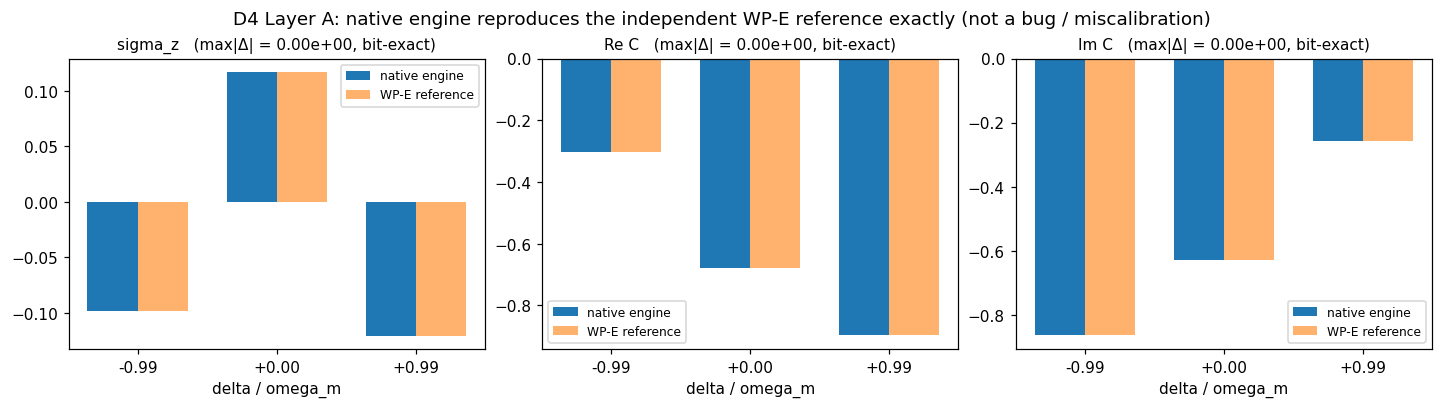

In [3]:
bn = json.load(open(os.path.join(NUM, "bridge_native.json")))
c1 = bn["comparison_1_nearest_grid"]
print(f"D4 Layer A: native engine vs independent WP-E reference "
      f"(threshold {c1['pass_threshold']:.0e}, "
      f"PASS={c1['pass']}, max residual = {c1['max_residual']:.2e})\n")
print(f"  {'delta/wm':>9} {'sigma_z (eng/ref)':>22} {'ReC (eng/ref)':>20} "
      f"{'ImC (eng/ref)':>20}")
for e, r in zip(c1["engine"], c1["reference"]):
    print(f"  {e['det_rel']:>+9.4f} "
          f"{e['sigma_z']:>+10.4f}/{r['sigma_z']:>+9.4f} "
          f"{e['C_real']:>+10.4f}/{r['C_real']:>+8.4f} "
          f"{e['C_imag']:>+10.4f}/{r['C_imag']:>+8.4f}")
print("\nconvention alignment recorded in the artefact:")
print("  -", bn["convention_alignment"]["mw_pi2_phase_alignment"][:96], "...")
print("  -", bn["convention_alignment"]["pulse_centering_alignment"][:96], "...")

fig, ax = plt.subplots(1, 3, figsize=(13, 3.6), constrained_layout=True)
labels = [f"{e['det_rel']:+.2f}" for e in c1["engine"]]
xp = np.arange(len(labels))
for a, key, ttl in zip(ax, ("sigma_z", "C_real", "C_imag"),
                        ("sigma_z", "Re C", "Im C")):
    eng = [e[key] for e in c1["engine"]]; ref = [r[key] for r in c1["reference"]]
    a.bar(xp - 0.18, eng, 0.36, label="native engine")
    a.bar(xp + 0.18, ref, 0.36, label="WP-E reference", alpha=0.6)
    a.set_xticks(xp); a.set_xticklabels(labels)
    a.set_title(f"{ttl}   (max|Δ| = {c1['max_residual']:.2e}, bit-exact)",
                fontsize=10)
    a.set_xlabel("delta / omega_m"); a.legend(fontsize=8)
fig.suptitle("D4 Layer A: native engine reproduces the independent "
             "WP-E reference exactly (not a bug / miscalibration)")
plt.show()

**Takeaway.** Engine and the independent WP-E reference are
bit-identical at every point — the native monochromatic engine is
implemented and calibrated correctly. Whatever §6 shows is therefore
*not* a defect to be fixed by tuning.

## §6 Evidence 3 — yet native ≠ ideal, structurally

Evidence 1 says the ideal maths is exact; Evidence 2 says the native
engine is correct. Now drive **both** with the *same* physical
control program (the back-action diagnostic, carrier $k{=}0$,
matched detuning/phase/$N$) and compare the motional state they
leave behind.

**What to look for:** the ideal SDF cleanly splits the motion into
two branches — its **σ_x-branch fidelity is exactly 1.000** at every
input. The native engine, *same program*, collapses to
$\sim0.04$–$0.35$, and the ideal-vs-native Wigner $L^1$ is $O(1)$.
Two correct implementations, same drive, different motion → the
operators differ. That is the structural mismatch of §2, measured.

Same control program, peak probe — does it split into clean branches?
     input  ideal sx-branch F   native sx-branch F   ideal-vs-native W L1
    vacuum             1.0000               0.3462                  0.813
     fock2             1.0000               0.0428                  1.813
    cat1.5             1.0000               0.1745                  1.872


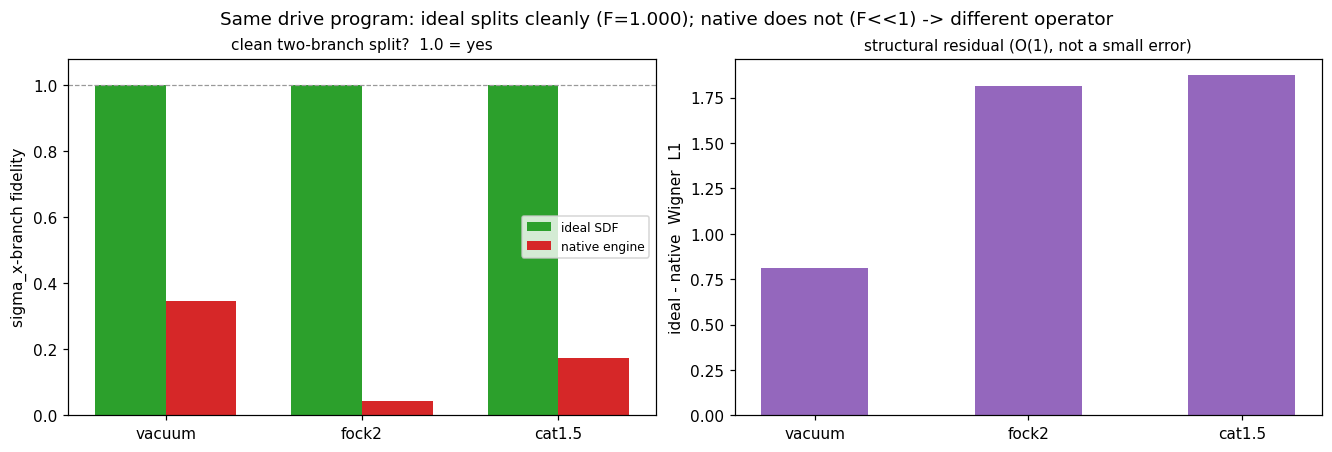

In [4]:
with h5py.File(os.path.join(NUM, "back_action.h5"), "r") as f:
    inputs = ["vacuum", "fock2", "cat1.5"]
    rows = {}
    for k in f:
        if not k.startswith("rec_"):
            continue
        g = f[k]
        if g.attrs["point"] != "peak":
            continue
        rows.setdefault(g.attrs["input"], {})[g.attrs["leg"]] = dict(
            sx=float(g["cond/x+"].attrs["branch_fidelity"]),
            L1=float(g.attrs["ideal_vs_native_W_L1"]))

print("Same control program, peak probe — does it split into clean branches?")
print(f"  {'input':>8} {'ideal sx-branch F':>18} {'native sx-branch F':>20} "
      f"{'ideal-vs-native W L1':>22}")
for inp in inputs:
    r = rows[inp]
    print(f"  {inp:>8} {r['ideal']['sx']:>18.4f} {r['native']['sx']:>20.4f} "
          f"{r['ideal']['L1']:>22.3f}")

fig, (a0, a1) = plt.subplots(1, 2, figsize=(12, 4.0), constrained_layout=True)
xp = np.arange(len(inputs))
a0.bar(xp - 0.18, [rows[i]["ideal"]["sx"] for i in inputs], 0.36,
       label="ideal SDF", color="tab:green")
a0.bar(xp + 0.18, [rows[i]["native"]["sx"] for i in inputs], 0.36,
       label="native engine", color="tab:red")
a0.axhline(1.0, ls="--", c="0.6", lw=0.8)
a0.set_xticks(xp); a0.set_xticklabels(inputs)
a0.set_ylim(0, 1.08); a0.set_ylabel("sigma_x-branch fidelity")
a0.set_title("clean two-branch split?  1.0 = yes", fontsize=10)
a0.legend(fontsize=8)
a1.bar(xp, [rows[i]["ideal"]["L1"] for i in inputs], 0.5, color="tab:purple")
a1.set_xticks(xp); a1.set_xticklabels(inputs)
a1.set_ylabel("ideal - native  Wigner  L1")
a1.set_title("structural residual (O(1), not a small error)", fontsize=10)
fig.suptitle("Same drive program: ideal splits cleanly (F=1.000); "
             "native does not (F<<1) -> different operator")
plt.show()

**Takeaway.** Identical control program; the ideal SDF's
branch fidelity is exactly 1.000 (it *is* a
spin-eigenstate-conditioned displacement) while the native engine
collapses to $0.04$–$0.35$ with an $O(1)$ Wigner $L^1$. Combined
with Evidence 1 (maths exact) and Evidence 2 (engine correct), the
gap can *only* be the operator difference of §2 — a measured
confirmation of the §7#3 structural finding.

## §7 What we currently understand

1. **It is not a calibration failure.** The ideal inversion is exact
   ($10^{-14}$ point, $3.75\times10^{-4}$ grid-wide); the native
   engine is bit-exact against an independent reference. Two
   separately-verified "correct" systems still disagree by $O(1)$
   under the same drive — that can only be a *different operator*.

2. **The operators are genuinely different.** Monochromatic Raman =
   carrier rotation + transverse position-dependent spin rotation
   (JC at the sideband); the FH20 SDF = spin-eigenstate-conditioned
   displacement. No scalar limit connects them; only a *bichromatic*
   MS-type drive would. Hence WP-W supplies the ideal SDF as a
   **separate primitive** rather than a regime of the engine.

3. **Therefore WP-W's two-layer policy.** The ideal-SDF tomography
   claim (notebooks 1–3) stands on its own, validated. The native
   bridge is a *measured diagnostic* — the back-action notebook's
   structural residual — never a fidelity gate. Keeping them
   separate is the correct scientific bookkeeping, not a workaround.

4. **Scope.** Carrier $k{=}0$, the matched-control comparison of the
   back-action diagnostic; the sideband ($k{=}1$, JC) regime where
   the native back-action is richest is a documented future variant
   (back-action notebook §6 / scope §4a). This notebook closes the
   explanatory series.

## §8 Provenance

In [5]:
def _git_short():
    try:
        return subprocess.check_output(
            ["git", "-C", REPO, "rev-parse", "--short", "HEAD"], text=True).strip()
    except Exception as e:
        return f"(unavailable: {e})"

print("notebook                       : notebooks/wpw_native_bridge.ipynb")
print("code/artefact commit @ exec    :", _git_short(),
      " (repo state the notebook was run against; the notebook's own"
      " commit is the next one)")
print("input artefacts (committed):")
for n in ("p1_preflight", "bridge_inversion", "back_action"):
    mp = os.path.join(NUM, n + ".manifest.json")
    m = json.load(open(mp))
    print(f"  {n+'.h5':22s} sha256={m['artifact']['sha256'][:16]}...  "
          f"provenance_hash={m['provenance_hash'][:16]}...")
bnp = os.path.join(NUM, "bridge_native.json")
print(f"  {'bridge_native.json':22s} sha256={_sha(bnp)[:16]}...  "
      f"(JSON runner output — no wp_manifest sidecar; hashed at load)")
print("\nhelpers/source of truth        : notes/analytic_chain.md §5 "
      "(the structural argument); _common.py (smoke-tested helpers)")
print("Synthesis artefact; the four committed artefacts above are the "
      "provenance-bound source of every number shown.")

notebook                       : notebooks/wpw_native_bridge.ipynb
code/artefact commit @ exec    : 2c27434  (repo state the notebook was run against; the notebook's own commit is the next one)
input artefacts (committed):
  p1_preflight.h5        sha256=c858b44cfeb3bca6...  provenance_hash=f60458e957d78542...
  bridge_inversion.h5    sha256=d8e8534209768f70...  provenance_hash=fe2e2e3ea9e282d6...
  back_action.h5         sha256=c2618faaa86f04d0...  provenance_hash=c1b523a16924e061...
  bridge_native.json     sha256=91caa6799882694c...  (JSON runner output — no wp_manifest sidecar; hashed at load)

helpers/source of truth        : notes/analytic_chain.md §5 (the structural argument); _common.py (smoke-tested helpers)
Synthesis artefact; the four committed artefacts above are the provenance-bound source of every number shown.


## §9 References

Verified subset (full bibliography + per-paper extractions:
[`WORK-PROGRAM.md`](../wp-wigner-tomography/WORK-PROGRAM.md)
§References — not duplicated here).

- **[FH20]** Flühmann & Home, Phys. Rev. Lett. **125**, 043602
  (2020). [doi:10.1103/PhysRevLett.125.043602](https://doi.org/10.1103/PhysRevLett.125.043602)
  — the *bichromatic* σ_x SDF the engine does **not** natively realise.
- **[Hasse24]** Hasse, Palani, Thomm, Warring, Schaetz, Phys. Rev. A
  **109**, 053105 (2024).
  [doi:10.1103/PhysRevA.109.053105](https://doi.org/10.1103/PhysRevA.109.053105)
  — the monochromatic stroboscopic protocol the native engine implements.
- **[Clos16]** Clos, Porras, Warring, Schaetz, Phys. Rev. Lett.
  **117**, 170401 (2016).
  [doi:10.1103/PhysRevLett.117.170401](https://doi.org/10.1103/PhysRevLett.117.170401)
  — Hasse-group predecessor establishing the $H_\mathrm{TI}$ form of §2.
- **[LBMW03]** Leibfried, Blatt, Monroe, Wineland, Rev. Mod. Phys.
  **75**, 281 (2003).
  [doi:10.1103/RevModPhys.75.281](https://doi.org/10.1103/RevModPhys.75.281)
  — Lamb–Dicke expansion / Jaynes–Cummings & MS coupling reference.

*Internal source of truth for the structural argument:
[`notes/analytic_chain.md`](../wp-wigner-tomography/notes/analytic_chain.md)
§5. This notebook shows the executed evidence; it does not re-derive.*